In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
import astropy.constants as const

In [2]:
def incline(y, z, inc):
    inc_ = np.deg2rad(inc)

    cosi = np.cos(inc_)
    sini = np.sin(inc_)

    y_f =  y*cosi - z*sini
    z_f =  y*sini + z*cosi
    return y_f, z_f
    

In [3]:
def matrix_mine(x, y, z, warp, twist, inc_, PA_):
    #print(warp)
    warp = warp[:, None, None]
    twist = twist[:, None, None]
    

    cosPA = np.cos(PA_)
    sinPA = np.sin(PA_)
    
    cosi = np.cos(inc_)
    sini = np.sin(inc_)

    '''making sure twist occurs before warp'''

    cosw = np.cos(warp)
    sinw = np.sin(warp)

    cost = np.cos(twist)
    sint = np.sin(twist)
    
    y_w = y*cosw - z*sinw
    z_w = y*sinw + z*cosw
    
    x_t = x*cost - y_w*sint
    y_t = x*sint + y_w*cost

    x_pa = x_t*cosPA - y_t*sinPA
    y_pa = x_t*sinPA + y_t*cosPA

    #self.z_w_max = np.max(z_w)
    #self.x_pa = x_pa
    #self.y_pa = y_pa
    #self.z_w = z_w

    #self.a_w, self.p_w = cart2pol(x_pa, y_pa)
    #self.zf_w = np.linspace(-z_w_max, z_w_max, self.nzc)
    #self.pf_w = np.linspace(-z_w_max, z_w_max, self.nzc)
    
    y_f =  y_pa*cosi - z_w*sini
    z_f =  y_pa*sini + z_w*cosi


    return x_pa, y_f, z_f

In [4]:

def cart2pol(x, y):
    rho = np.sqrt(x**2 + y**2)
    phi = np.arctan2(y, x)
    return(rho, phi)

def pol2cart(rho, phi):
    x = rho * np.cos(phi)
    y = rho * np.sin(phi)
    return(x, y)

In [5]:
def w_func(a, r0, dr, r, type):
    #r0 = self.w_r0
    #dr = self.w_dr

    '''same general function for warp & twist, just need to specify which param to use'''
    #if type == "w":
        #a = self.w_i

    #elif type == "pa":
        #a = self.pa
    
    
    r0 = 1.0 if r0 is None else r0
    dr = 1.0 if dr is None else dr
    return np.radians(a / (1.0 + np.exp(-(r0 - r) / (0.1*dr)))) 

In [6]:
def w_func_global(value, glob, r0, dr, r, type):
    a = value + glob
    #r0 = self.w_r0
    #dr = self.w_dr

    '''same general function for warp & twist, just need to specify which param to use'''
    #if type == "w":
        #a = self.w_i

    #elif type == "pa":
        #a = self.pa
    
    
    r0 = 1.0 if r0 is None else r0
    dr = 1.0 if dr is None else dr
    return np.radians(a / (1.0 + np.exp(-(r0 - r) / (0.1*dr)))) 

In [63]:
af = np.linspace(0,200,100)
zf = np.linspace(-30,30,20)
#zf_warp = np.linspace(zmin+1,self.zmax-1,nzc-2)
pf = np.linspace(0,2*np.pi,100)

In [156]:
w_i = 0
w_pa = 0

inc = 80
pa = 60

r0 = 50
dr = 100

In [157]:
warp_i  = w_func(w_i, 70, 50, af, type="w")

twist_i = w_func(w_pa,70, 50, af, type="pa")

In [158]:
pcf,acf,zcf = np.meshgrid(pf,af,zf)
xi, yi = pol2cart(acf, pcf)

x_w, y_w, z_w = matrix_mine(xi, yi, zcf, warp_i, twist_i, np.deg2rad(inc), np.deg2rad(pa))

r_w, p_w = cart2pol(x_w, y_w)

ty, tz = incline(yi, zcf, inc)

/tmp/ipykernel_32764/2881684419.py:1: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], y_w[:,:,10], z_w[:,:,10])


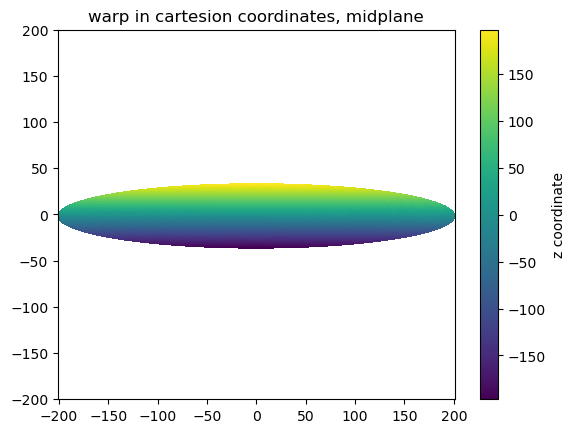

In [159]:
plt.pcolor(x_w[:,:,10], y_w[:,:,10], z_w[:,:,10])
plt.colorbar(label="z coordinate")
plt.title("warp in cartesion coordinates, midplane")
plt.ylim(-200,200)
plt.show()

In [160]:
#km^3/Sol mass s^2
G = 1.3271244002e11 * u.km**3 / (u.solMass * u.second**2)
G_unit = G.to(u.AU**3/ (u.solMass * u.second**2))
#G_unit
star_mass =2


In [161]:
warp_global_incl = w_func_global(w_i, inc, 70,50, af, type="w")

In [162]:
vel_kep = np.sqrt(G.value*star_mass/(acf*u.au.to(u.km)))*(np.cos(pcf))*np.sin(np.deg2rad(inc))

/tmp/ipykernel_32764/448744903.py:1: RuntimeWarning: divide by zero encountered in divide
  vel_kep = np.sqrt(G.value*star_mass/(acf*u.au.to(u.km)))*(np.cos(pcf))*np.sin(np.deg2rad(inc))


In [163]:
np.sin(np.deg2rad(inc))

0.984807753012208

In [164]:
vel_w = np.sqrt(G.value*star_mass/(r_w*u.au.to(u.km)))*(np.cos(p_w))*np.sin(warp_global_incl[:,None,None])

In [165]:
np.sin(warp_global_incl[:,None,None])

array([[[9.84807551e-01]],

       [[9.84807451e-01]],

       [[9.84807301e-01]],

       [[9.84807075e-01]],

       [[9.84806738e-01]],

       [[9.84806233e-01]],

       [[9.84805476e-01]],

       [[9.84804342e-01]],

       [[9.84802644e-01]],

       [[9.84800100e-01]],

       [[9.84796290e-01]],

       [[9.84790582e-01]],

       [[9.84782030e-01]],

       [[9.84769217e-01]],

       [[9.84750018e-01]],

       [[9.84721244e-01]],

       [[9.84678107e-01]],

       [[9.84613409e-01]],

       [[9.84516311e-01]],

       [[9.84370450e-01]],

       [[9.84151029e-01]],

       [[9.83820268e-01]],

       [[9.83320176e-01]],

       [[9.82560816e-01]],

       [[9.81400852e-01]],

       [[9.79614549e-01]],

       [[9.76835020e-01]],

       [[9.72456619e-01]],

       [[9.65471661e-01]],

       [[9.54217304e-01]],

       [[9.36045700e-01]],

       [[9.07060419e-01]],

       [[8.62323798e-01]],

       [[7.97167985e-01]],

       [[7.09847908e-01]],

       [[6.04271268e

/tmp/ipykernel_32764/3252333006.py:1: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(xi[:,:,0], ty[:,:,0], vel_kep[:,:,0], vmin=-10, vmax=10)


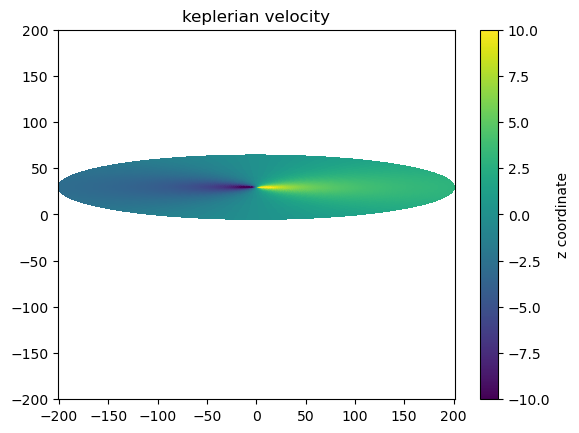

In [166]:
plt.pcolor(xi[:,:,0], ty[:,:,0], vel_kep[:,:,0], vmin=-10, vmax=10)
plt.colorbar(label="z coordinate")
plt.title("keplerian velocity")
plt.ylim(-200,200)
plt.show()

/tmp/ipykernel_32764/4179213067.py:1: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], y_w[:,:,10], vel_w[:,:,10], vmin=-10, vmax=10)


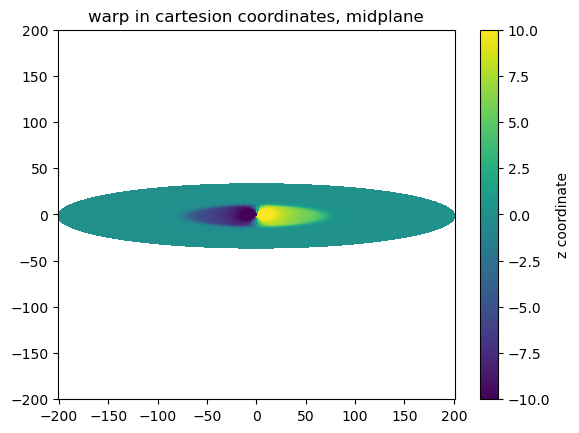

In [167]:
plt.pcolor(x_w[:,:,10], y_w[:,:,10], vel_w[:,:,10], vmin=-10, vmax=10)
plt.colorbar(label="z coordinate")
plt.title("warp in cartesion coordinates, midplane")
plt.ylim(-200,200)
plt.show()

/tmp/ipykernel_32764/3446988891.py:1: UserWarning: The input coordinates to pcolor are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolor.
  plt.pcolor(x_w[:,:,10], y_w[:,:,10], vel_w[:,:,10] - vel_kep[:,:,10], vmin=-10, vmax=10)


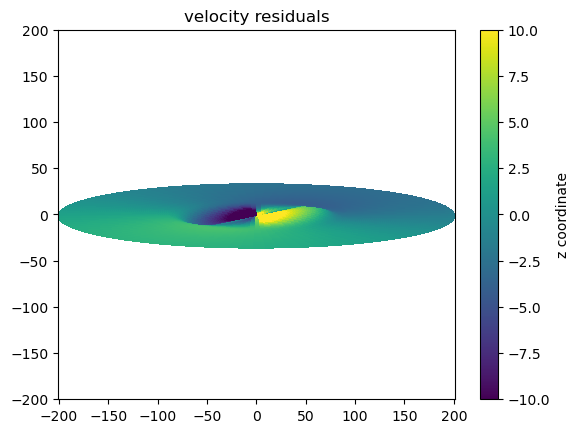

In [155]:
plt.pcolor(x_w[:,:,10], y_w[:,:,10], vel_w[:,:,10] - vel_kep[:,:,10], vmin=-10, vmax=10)
plt.colorbar(label="z coordinate")
plt.title("velocity residuals")
plt.ylim(-200,200)
plt.show()